In [1]:
# Implementation of ry_feature_map suitable for a quantum kernel
from qiskit import QuantumCircuit
import numpy as np

def ry_feature_map(n_qubits, data, entanglement="ring"):
    """
    Build a feature map with two Ry encoding layers separated by a configurable
    entanglement block.


    Parameters:
    - n_qubits: int, number of qubits (expected length of `data`)
    - data: iterable of real values with length `n_qubits`
    - entanglement: 'chain' | 'ring' | 'all_to_all'

    Returns:
    - QuantumCircuit (no measurements)
    """
    arr = np.asarray(data, dtype=float).ravel()
    if arr.size != n_qubits:
        raise ValueError(f"data must have length equal to n_qubits ({n_qubits}); got {arr.size}")

    qc = QuantumCircuit(n_qubits)

    # First encoding layer
    for q in range(n_qubits):
        qc.ry(arr[q], q)

    ent = (entanglement or "").lower()
    if ent == "chain":
        for i in range(n_qubits - 1):
            qc.cx(i, i + 1)
    elif ent == "ring":
        for i in range(n_qubits - 1):
            qc.cx(i, i + 1)
        if n_qubits > 1:
            qc.cx(n_qubits - 1, 0)
    elif ent == "all_to_all":
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                qc.cx(i, j)
    else:
        raise ValueError("Unsupported entanglement pattern. Choose 'chain', 'ring' or 'all_to_all'.")

    # Second encoding layer (same qubits, same encoding type)
    for q in range(n_qubits):
        qc.ry(arr[q], q)

    return qc

In [2]:
def phase_feature_map(n_qubits, data, entanglement="ring"):
    """
    Build a feature map that encodes `data` as Z-phase rotations (Rz) on each qubit
    after preparing equal superposition states with Hadamards, using two encoding
    layers separated by a configurable entanglement block.


    Parameters:
    - n_qubits: int, number of qubits (expected length of `data`)
    - data: iterable of real values with length `n_qubits`
    - entanglement: 'chain' | 'ring' | 'all_to_all'

    Returns:
    - QuantumCircuit (no measurements)
    """
    arr = np.asarray(data, dtype=float).ravel()
    if arr.size != n_qubits:
        raise ValueError(f"data must have length equal to n_qubits ({n_qubits}); got {arr.size}")

    qc = QuantumCircuit(n_qubits)

    # Prepare |+> states on all qubits
    for q in range(n_qubits):
        qc.h(q)

    # First encoding layer
    for q in range(n_qubits):
        qc.rz(arr[q], q)

    ent = (entanglement or "").lower()
    if ent == "chain":
        for i in range(n_qubits - 1):
            qc.cz(i, i + 1)
    elif ent == "ring":
        for i in range(n_qubits - 1):
            qc.cz(i, i + 1)
        if n_qubits > 1:
            qc.cz(n_qubits - 1, 0)
    elif ent == "all_to_all":
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                qc.cz(i, j)
    else:
        raise ValueError("Unsupported entanglement pattern. Choose 'chain', 'ring' or 'all_to_all'.")

    # Second encoding layer (same qubits, same encoding type)
    for q in range(n_qubits):
        qc.rz(arr[q], q)

    return qc

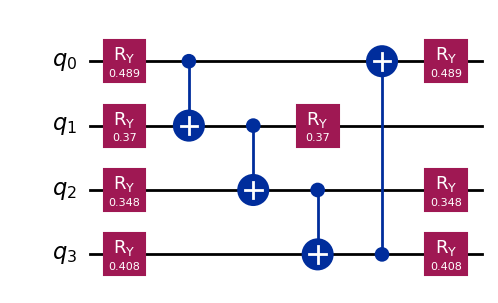

In [3]:
# Example usage: construct and visualize a circuit for 4 qubits
from qiskit.visualization import circuit_drawer

# Example data (must have length equal to n_qubits)
data = [0.48854, 0.36986, 0.34778, 0.40850]
qc = ry_feature_map(4, data, entanglement="ring")

# Display the circuit in the notebook (uses matplotlib if available)
qc.draw(output="mpl")

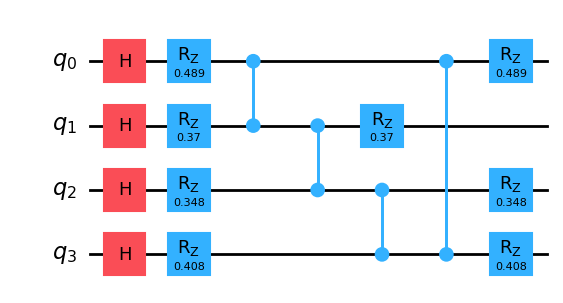

In [4]:
# Example usage: construct and visualize a circuit for 4 qubits
from qiskit.visualization import circuit_drawer

# Example data (must have length equal to n_qubits)
data = [0.48854, 0.36986, 0.34778, 0.40850]
qc = phase_feature_map(4, data, entanglement="ring")

# Display the circuit in the notebook (uses matplotlib if available)
qc.draw(output="mpl")

## Datuak kargau

### EEG

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split

# Cargar dataset preprocesado (features extraídas con preprocess.py)
dataset = np.load("data/processed_features.npz", allow_pickle=True)

X_angle = dataset["X_angle"]
X_raw = dataset["X_raw"]
y = dataset["y"]
y_name = dataset["y_name"]
feature_names = dataset["feature_names"]

print("X_angle:", X_angle.shape, "| X_raw:", X_raw.shape)
print("y:", y.shape, "| clases:", dict(zip(*np.unique(y_name, return_counts=True))))
print("N features:", len(feature_names))

X_angle: (80556, 19) | X_raw: (80556, 19)
y: (80556,) | clases: {np.str_('norm'): np.int64(37401), np.str_('sch'): np.int64(43155)}
N features: 19


In [6]:
from dataclasses import dataclass

@dataclass
class PipelineConfig:
    use_angles: bool = True
    test_size: float = 0.2
    random_state: int = 42
    train_frac: float = 0.2
    test_frac: float = 0.2
    n_qubits: int = 8
    n_train: int = 300
    n_test: int = 150
    svm_c: float = 1.0
    entanglement: str = "ring"

cfg = PipelineConfig()
print(cfg)

PipelineConfig(use_angles=True, test_size=0.2, random_state=42, train_frac=0.2, test_frac=0.2, n_qubits=8, n_train=300, n_test=150, svm_c=1.0, entanglement='ring')


In [7]:
from qiskit.quantum_info import Statevector

# =========================
# Quantum kernel (fidelity)
# =========================
def _state(x, fm, entanglement="ring"):
    if fm == "ry":
        qc = ry_feature_map(n_qubits=len(x), data=x, entanglement=entanglement)
    elif fm == "rz":
        qc = phase_feature_map(n_qubits=len(x), data=x, entanglement=entanglement)
    else:
        raise ValueError("Unsupported feature map. Choose 'ry' or 'rz'.")
    return Statevector.from_instruction(qc).data

def _fidelity(x1, x2, fm, entanglement="ring"):
    psi1 = _state(x1, fm, entanglement=entanglement)
    psi2 = _state(x2, fm, entanglement=entanglement)
    return float(np.abs(np.vdot(psi1, psi2)) ** 2)

def kernel_matrix(A, B, fm, entanglement="ring"):
    K = np.zeros((len(A), len(B)), dtype=np.float64)
    for i in range(len(A)):
        for j in range(len(B)):
            K[i, j] = _fidelity(A[i], B[j], fm, entanglement=entanglement)
    return K

In [8]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

def run_quantum_svm_pipeline(dataset, fm, cfg):
    X_full = dataset["X_angle"] if cfg.use_angles else dataset["X_raw"]
    y_full = dataset["y"]
    y_name_full = dataset["y_name"]

    idx = np.arange(len(y_full))
    idx_train, idx_test = train_test_split(
        idx,
        test_size=cfg.test_size,
        random_state=cfg.random_state,
        stratify=y_full,
    )

    X_train, X_test = X_full[idx_train], X_full[idx_test]
    y_train, y_test = y_full[idx_train], y_full[idx_test]
    y_name_train, y_name_test = y_name_full[idx_train], y_name_full[idx_test]

    X_train_sub, _, y_train_sub, _, y_name_train_sub, _ = train_test_split(
        X_train, y_train, y_name_train,
        train_size=cfg.train_frac,
        random_state=cfg.random_state,
        stratify=y_train,
    )

    X_test_sub, _, y_test_sub, _, y_name_test_sub, _ = train_test_split(
        X_test, y_test, y_name_test,
        train_size=cfg.test_frac,
        random_state=cfg.random_state,
        stratify=y_test,
    )

    X_train_q = X_train_sub[: cfg.n_train, : cfg.n_qubits]
    X_test_q = X_test_sub[: cfg.n_test, : cfg.n_qubits]
    y_train_q = y_train_sub[: cfg.n_train]
    y_test_q = y_test_sub[: cfg.n_test]

    print(f"\n=== Running pipeline fm={fm} ===")
    print("Train subset:", X_train_q.shape, "| Test subset:", X_test_q.shape)
    print("Class train:", dict(zip(*np.unique(y_name_train_sub, return_counts=True))))
    print("Class test :", dict(zip(*np.unique(y_name_test_sub, return_counts=True))))

    K_train = kernel_matrix(X_train_q, X_train_q, fm=fm, entanglement=cfg.entanglement)
    K_test = kernel_matrix(X_test_q, X_train_q, fm=fm, entanglement=cfg.entanglement)

    clf = SVC(kernel="precomputed", C=cfg.svm_c)
    clf.fit(K_train, y_train_q)
    y_pred = clf.predict(K_test)

    acc = accuracy_score(y_test_q, y_pred)
    report = classification_report(y_test_q, y_pred, target_names=["norm", "sch"])

    print("K_train:", K_train.shape, "| K_test:", K_test.shape)
    print("Accuracy:", acc)
    print(report)

    return {
        "fm": fm,
        "accuracy": acc,
        "report": report,
        "K_train": K_train,
        "K_test": K_test,
        "y_true": y_test_q,
        "y_pred": y_pred,
    }

result_rz = run_quantum_svm_pipeline(dataset, fm="rz", cfg=cfg)
result_ry = run_quantum_svm_pipeline(dataset, fm="ry", cfg=cfg)

print("\nSummary accuracy:")
print({"rz": result_rz["accuracy"], "ry": result_ry["accuracy"]})


=== Running pipeline fm=rz ===
Train subset: (300, 8) | Test subset: (150, 8)
Class train: {np.str_('norm'): np.int64(5984), np.str_('sch'): np.int64(6904)}
Class test : {np.str_('norm'): np.int64(1496), np.str_('sch'): np.int64(1726)}
K_train: (300, 300) | K_test: (150, 300)
Accuracy: 0.64
              precision    recall  f1-score   support

        norm       0.71      0.39      0.50        70
         sch       0.62      0.86      0.72        80

    accuracy                           0.64       150
   macro avg       0.66      0.62      0.61       150
weighted avg       0.66      0.64      0.62       150


=== Running pipeline fm=ry ===
Train subset: (300, 8) | Test subset: (150, 8)
Class train: {np.str_('norm'): np.int64(5984), np.str_('sch'): np.int64(6904)}
Class test : {np.str_('norm'): np.int64(1496), np.str_('sch'): np.int64(1726)}
K_train: (300, 300) | K_test: (150, 300)
Accuracy: 0.6333333333333333
              precision    recall  f1-score   support

        norm      